<a href="https://colab.research.google.com/github/shah15rizal/businesscoffea/blob/main/coffea-business-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


DATA PREVIEW
        date                datetime cash_type                 card  money  \
0 2024-03-01 2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1 2024-03-01 2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2 2024-03-01 2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3 2024-03-01 2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4 2024-03-01 2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  hour  
0          Latte    10  
1  Hot Chocolate    12  
2  Hot Chocolate    12  
3      Americano    13  
4          Latte    13  

TOTAL REVENUE
115431.58

TOTAL TRANSACTION
3636

TOP PRODUCT
           coffee_name  total_sales  total_revenue
0  Americano with Milk          824       25269.12
1                Latte          782       27866.30
2            Americano          578       15062.26
3           Cappuccino          501       18034.14
4              Cortado          292        7534.86

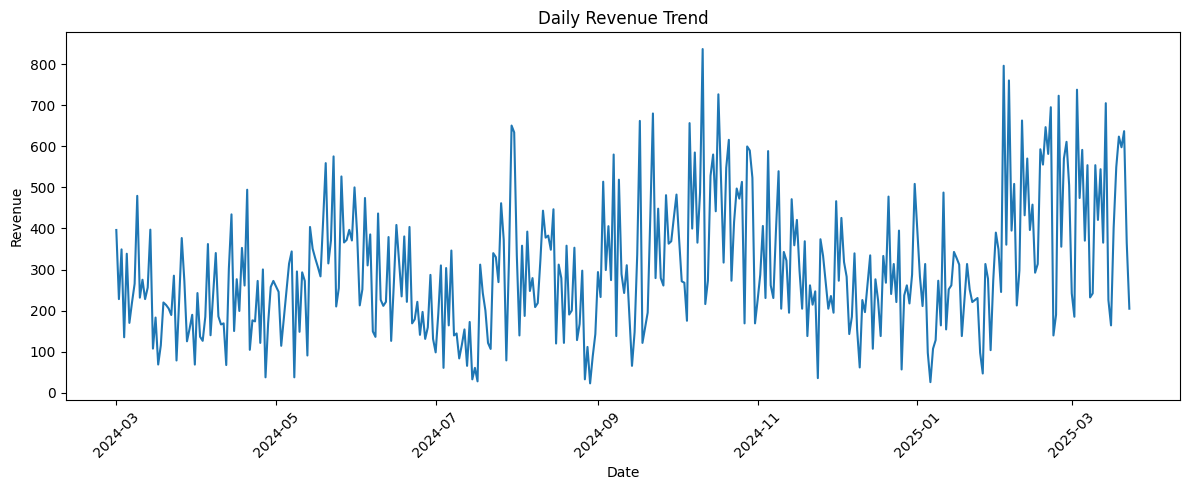


BUSINESS INSIGHT
1. Products with the highest revenue can be positioned as signature products.
2. Peak hours can be used to optimize employee shift scheduling.
3. The dominance of digital payments creates opportunities for e-wallet promotions and cashback strategies.
4. Loyal customers can be targeted through membership and reward programs.
5. Daily revenue trends can support sales forecasting and business planning.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt


def coffee_sales_analysis(file_path):

    # =========================
    # IMPORT DATA
    # =========================
    df = pd.read_csv('/content/index_1.csv')

    # =========================
    # DATA PREPARATION
    # =========================
    df['date'] = pd.to_datetime(df['date'])
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour'] = df['datetime'].dt.hour

    print("""
==============================""")
    print("DATA PREVIEW")
    print("==============================")
    print(df.head())

    # =========================
    # TOTAL REVENUE
    # =========================
    total_revenue = df['money'].sum()

    print("""
==============================""")
    print("TOTAL REVENUE")
    print("==============================")
    print(total_revenue)

    # =========================
    # TOTAL TRANSACTION
    # =========================
    total_transaction = len(df)

    print("""
==============================""")
    print("TOTAL TRANSACTION")
    print("==============================")
    print(total_transaction)

    # =========================
    # TOP PRODUCT
    # =========================
    top_product = (
        df.groupby('coffee_name')
        .agg(
            total_sales=('coffee_name', 'count'),
            total_revenue=('money', 'sum')
        )
        .sort_values(by='total_sales', ascending=False)
        .reset_index()
    )

    print("""
==============================""")
    print("TOP PRODUCT")
    print("==============================")
    print(top_product)

    # =========================
    # REVENUE BY PRODUCT
    # =========================
    revenue_product = (
        df.groupby('coffee_name')['money']
        .sum()
        .reset_index(name='revenue')
        .sort_values(by='revenue', ascending=False)
    )

    print("""
==============================""")
    print("REVENUE BY PRODUCT")
    print("==============================")
    print(revenue_product)

    # =========================
    # PEAK HOUR ANALYSIS
    # =========================
    peak_hour = (
        df.groupby('hour')
        .size()
        .reset_index(name='total_transaction')
        .sort_values(by='total_transaction', ascending=False)
    )

    print("""
==============================""")
    print("PEAK HOUR ANALYSIS")
    print("==============================")
    print(peak_hour)

    # =========================
    # PAYMENT ANALYSIS
    # =========================
    payment_analysis = (
        df.groupby('cash_type')
        .size()
        .reset_index(name='total_transaction')
    )

    payment_analysis['percentage'] = (
        payment_analysis['total_transaction'] /
        payment_analysis['total_transaction'].sum() * 100
    )

    print("""
==============================""")
    print("PAYMENT ANALYSIS")
    print("==============================")
    print(payment_analysis)

    # =========================
    # DAILY REVENUE TREND
    # =========================
    daily_sales = (
        df.groupby('date')['money']
        .sum()
        .reset_index(name='daily_revenue')
    )

    print("""
==============================""")
    print("DAILY REVENUE TREND")
    print("==============================")
    print(daily_sales)

    # =========================
    # CUSTOMER FREQUENCY
    # =========================
    customer_freq = (
        df.groupby('card')
        .size()
        .reset_index(name='total_transaction')
        .sort_values(by='total_transaction', ascending=False)
    )

    print("""
==============================""")
    print("CUSTOMER FREQUENCY")
    print("==============================")
    print(customer_freq.head(10))

    # =========================
    # VISUALIZATION
    # =========================
    plt.figure(figsize=(12, 5))
    plt.plot(daily_sales['date'], daily_sales['daily_revenue'])
    plt.title('Daily Revenue Trend')
    plt.xlabel('Date')
    plt.ylabel('Revenue')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # =========================
    # BUSINESS INSIGHT
    # =========================
    print("""
==============================""")
    print("BUSINESS INSIGHT")
    print("==============================")
    print("1. Products with the highest revenue can be positioned as signature products.")
    print("2. Peak hours can be used to optimize employee shift scheduling.")
    print("3. The dominance of digital payments creates opportunities for e-wallet promotions and cashback strategies.")
    print("4. Loyal customers can be targeted through membership and reward programs.")
    print("5. Daily revenue trends can support sales forecasting and business planning.")

# =========================
# RUN PROGRAM
# =========================
coffee_sales_analysis('coffee_sales.csv')
